In [7]:
import sys

import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from PIL import Image
# Supprimer le module du cache
if 'rd_encoder' in sys.modules:
    del sys.modules['rd_encoder']

# Import frais
from encoder import rd_encoder
from encoder import ra_encoder

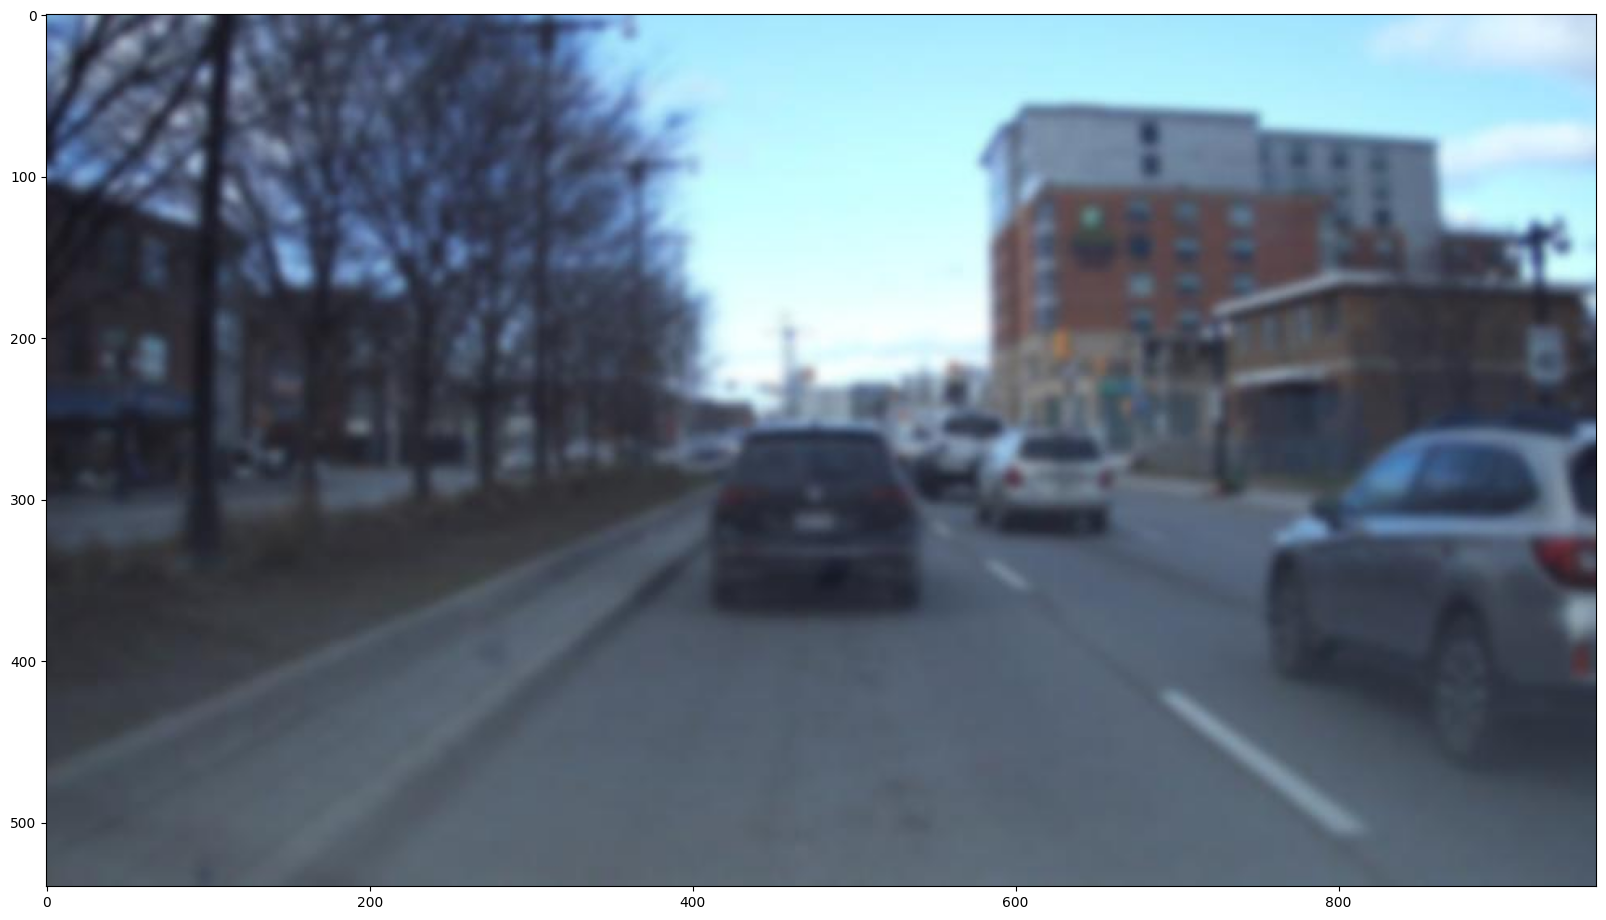

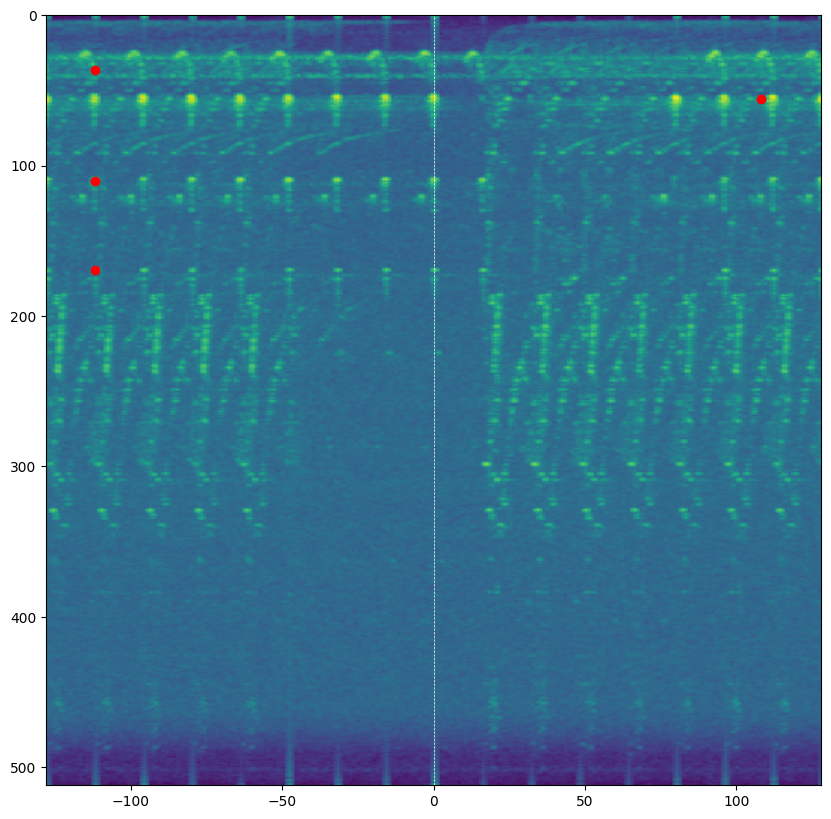

In [2]:
labels = pd.read_csv(os.path.join("/Benson_DATA3/Public/RADIal/ready_to_use/RADIal",'labels.csv')).to_numpy()
unique_ids = np.unique(labels[:,0])
label_dict = {}
for i,ids in enumerate(unique_ids):
    sample_ids = np.where(labels[:,0]==ids)[0]
    label_dict[ids]=sample_ids
sample_keys = list(label_dict.keys())

sample_id = sample_keys[0]
entries_indexes = label_dict[sample_id]
box_labels = labels[entries_indexes]
box_labels = box_labels[:,[10,11,12,5,6,7,1,2,3,4]].astype(np.float32) 
radar_name = os.path.join("/Benson_DATA3/Public/RADIal/ready_to_use/RADIal",'RD_Shift',"fft_{:06d}.npy".format(sample_id))

img_name = os.path.join("/Benson_DATA3/Public/RADIal/ready_to_use/RADIal",'camera',"image_{:06d}.jpg".format(sample_id))
image = np.asarray(Image.open(img_name))

plt.figure(figsize=(20,20))
plt.imshow(image)

radar_FFT = np.load(radar_name,allow_pickle=True)
radar_FFT = radar_FFT[...,::2]+1j*radar_FFT[...,1::2]
power_spectrum = np.sum(np.abs(radar_FFT),axis=2)
N_range, N_doppler = power_spectrum.shape
half_d = N_doppler // 2

plt.figure(figsize=(10,10))
# extent: [x_left, x_right, y_bottom, y_top] — Doppler centered at 0
plt.imshow(np.log10(power_spectrum), extent=[-half_d, half_d, N_range, 0], aspect='auto')
plt.axvline(x=0, color='white', linewidth=0.5, linestyle='--')

for box in box_labels:
    if(box[0]==-1):
        break # -1 means no object
    Range = box[0] * 512/103 # 512 range bins for 103m
    Doppler = box[2] - half_d          # already in centered coordinates
    plt.plot(Doppler, Range, 'ro')


In [3]:
geometry = {
    "ranges": [512,256],
    "resolution": [0.201171875,0.1],
    "size": 1
}

statistics = {
    "reg_mean":[0.40421298, 1.4390292 ],
    "reg_std":[0.69709622, 1.1349391 ]
}

encoder = rd_encoder(geometry, statistics, regression_layer=2)  

encoded_map = encoder.encode(box_labels)
print(f"\nEncoded map shape: {encoded_map.shape}")
print(f"  Channel 0 (classification): {np.sum(encoded_map[0] > 0)} detections")
print(f"  Channel 1 (range offset): min={encoded_map[1].min():.3f}, max={encoded_map[1].max():.3f}")
print(f"  Channel 2 (doppler offset): min={encoded_map[2].min():.3f}, max={encoded_map[2].max():.3f}")




Encoded map shape: (3, 128, 64)
  Channel 0 (classification): 4 detections
  Channel 1 (range offset): min=-0.374, max=0.449
  Channel 2 (doppler offset): min=-1.268, max=0.000


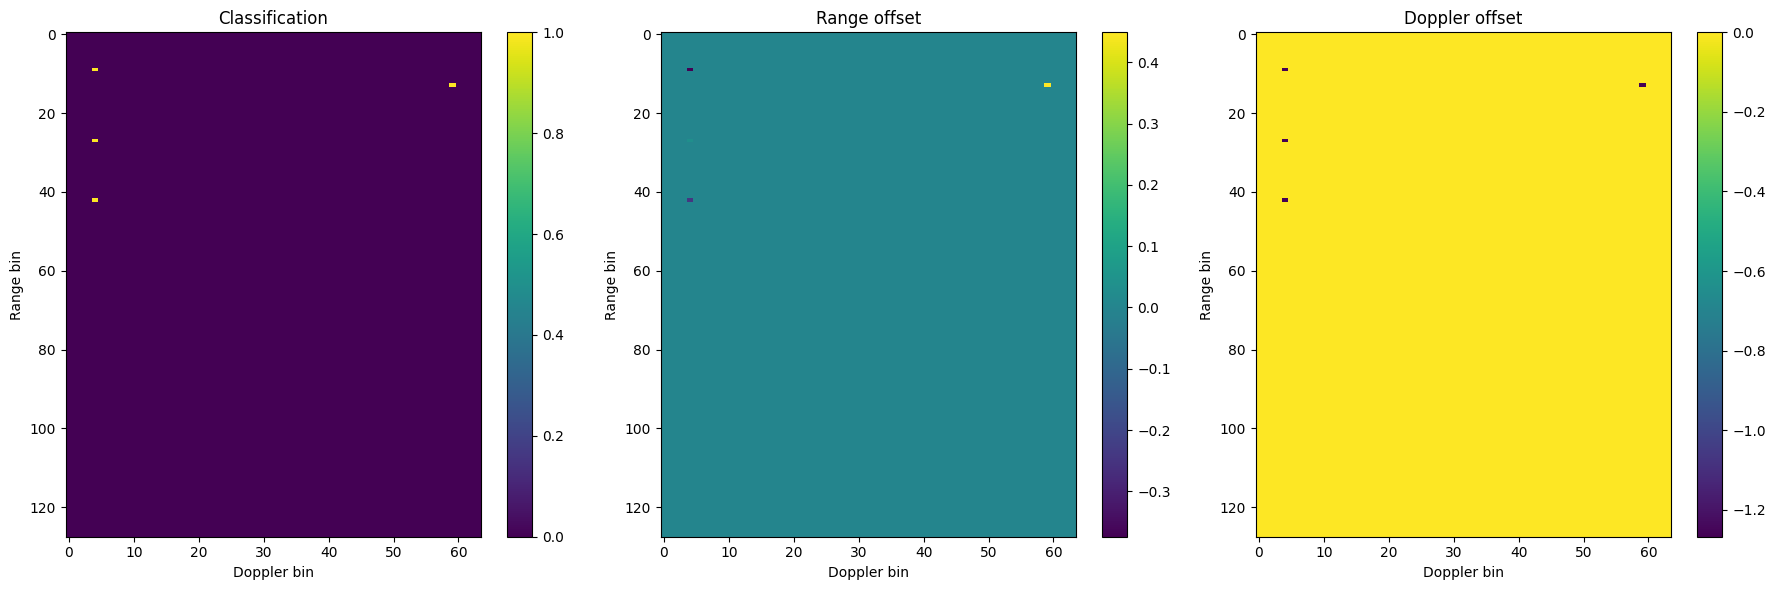

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Classification', 'Range offset', 'Doppler offset']
for i, (ax, title) in enumerate(zip(axes, titles)):
    im = ax.imshow(encoded_map[i], origin='upper', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Doppler bin')
    ax.set_ylabel('Range bin')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [5]:
decoded = encoder.decode(encoded_map, threshold=0.05)

print(f"{len(decoded)} detections decoded:\n")
print(f"{'Range (m)':>12}  {'Doppler (bin)':>14}  {'Score':>8}")
print("-" * 40)
for R, D, C in decoded:
    print(f"{R:>12.2f}  {D:>14.2f}  {C:>8.3f}")


4 detections decoded:

   Range (m)   Doppler (bin)     Score
----------------------------------------
        7.39         -112.00     1.000
       11.18          108.00     1.000
       22.16         -112.00     1.000
       34.03         -112.00     1.000


In [11]:
geometry= {
            "ranges": [512,896,1],
            "resolution": [0.201171875,0.2],
            "size": 1
        }
statistics = {
    "reg_mean":[0.4048094369863972,0.3997392847799934],
    "reg_std":[0.6968599580482511,0.6942950877813826]
}
encoder = ra_encoder(geometry, statistics, regression_layer=2)  

encoded_map = encoder.encode(box_labels)
print(f"\nEncoded map shape: {encoded_map.shape}")
print(f"  Channel 0 (classification): {np.sum(encoded_map[0] > 0)} detections")
print(f"  Channel 1 (range offset): min={encoded_map[1].min():.3f}, max={encoded_map[1].max():.3f}")
print(f"  Channel 2 (doppler offset): min={encoded_map[2].min():.3f}, max={encoded_map[2].max():.3f}")


Encoded map shape: (3, 128, 224)
  Channel 0 (classification): 4 detections
  Channel 1 (range offset): min=-0.375, max=0.448
  Channel 2 (doppler offset): min=-0.576, max=0.432


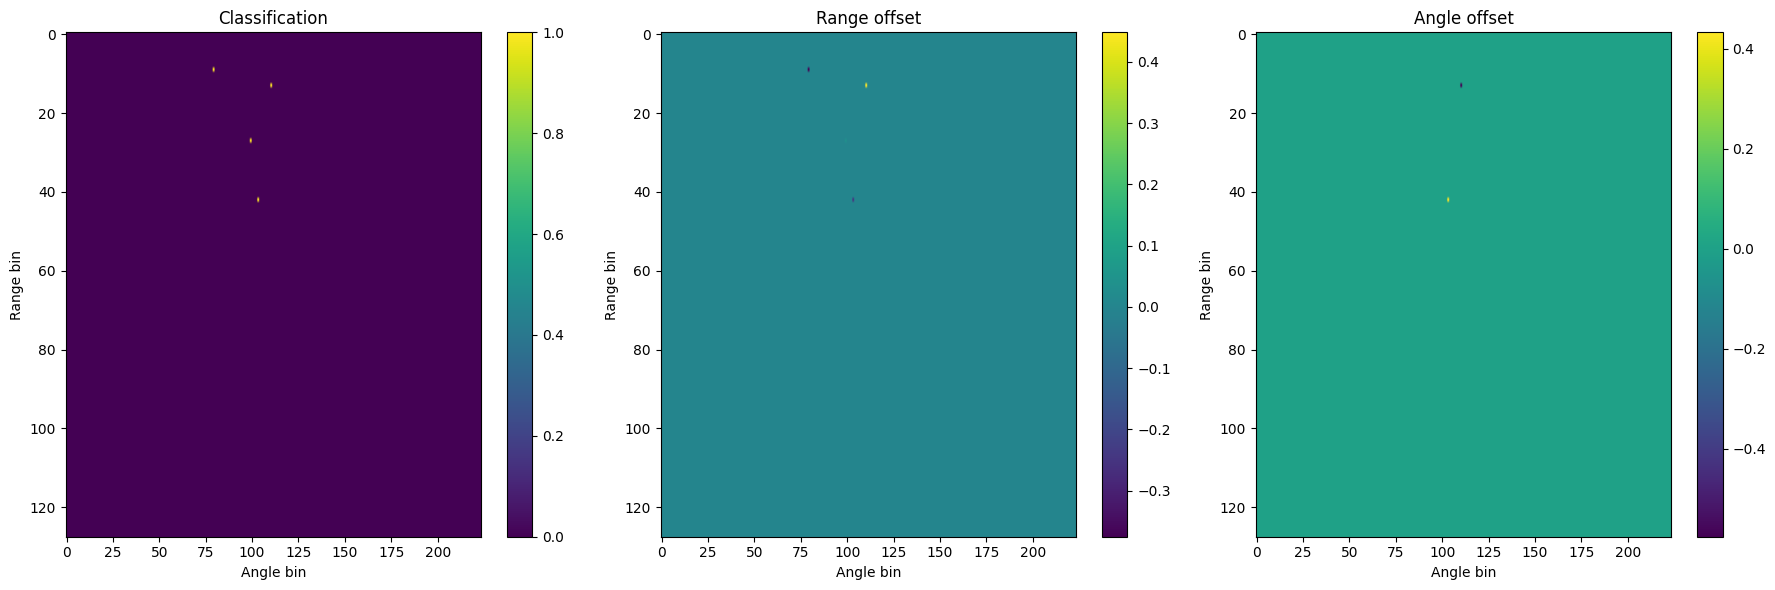

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Classification', 'Range offset', 'Angle offset']
for i, (ax, title) in enumerate(zip(axes, titles)):
    im = ax.imshow(encoded_map[i], origin='upper', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Angle bin')
    ax.set_ylabel('Range bin')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [15]:
decoded = encoder.decode(encoded_map, threshold=0.05)

print(f"{len(decoded)} detections decoded:\n")
print(f"{'Range (m)':>12}  {'Angle (bin)':>14}  {'Score':>8}")
print("-" * 40)
for R, D, C in decoded:
    print(f"{R:>12.2f}  {D:>14.2f}  {C:>8.3f}")

4 detections decoded:

   Range (m)     Angle (bin)     Score
----------------------------------------
        7.39          -26.00     1.000
       11.18           -1.60     1.000
       22.16          -10.00     1.000
       34.03           -6.50     1.000
